In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

with open('../outputs/classical/results.json') as f:
    rf = json.load(f)

print(rf)

{'elev_std': {'best_params': {'max_depth': 20, 'n_estimators': 200}, 'train_mae': 19.8554, 'train_rmse': 27.344, 'val_mae': 41.2931, 'val_rmse': 58.3944}, 'elev_mean': {'best_params': {'max_depth': 20, 'n_estimators': 200}, 'train_mae': 0.4513, 'train_rmse': 0.8047, 'val_mae': 0.5416, 'val_rmse': 1.1864}, 'slope_dir': {'best_params': {'max_depth': 20, 'n_estimators': 200}, 'train_mae': 26.5287, 'train_rmse': 32.1248, 'val_mae': 43.5922, 'val_rmse': 51.1042}}


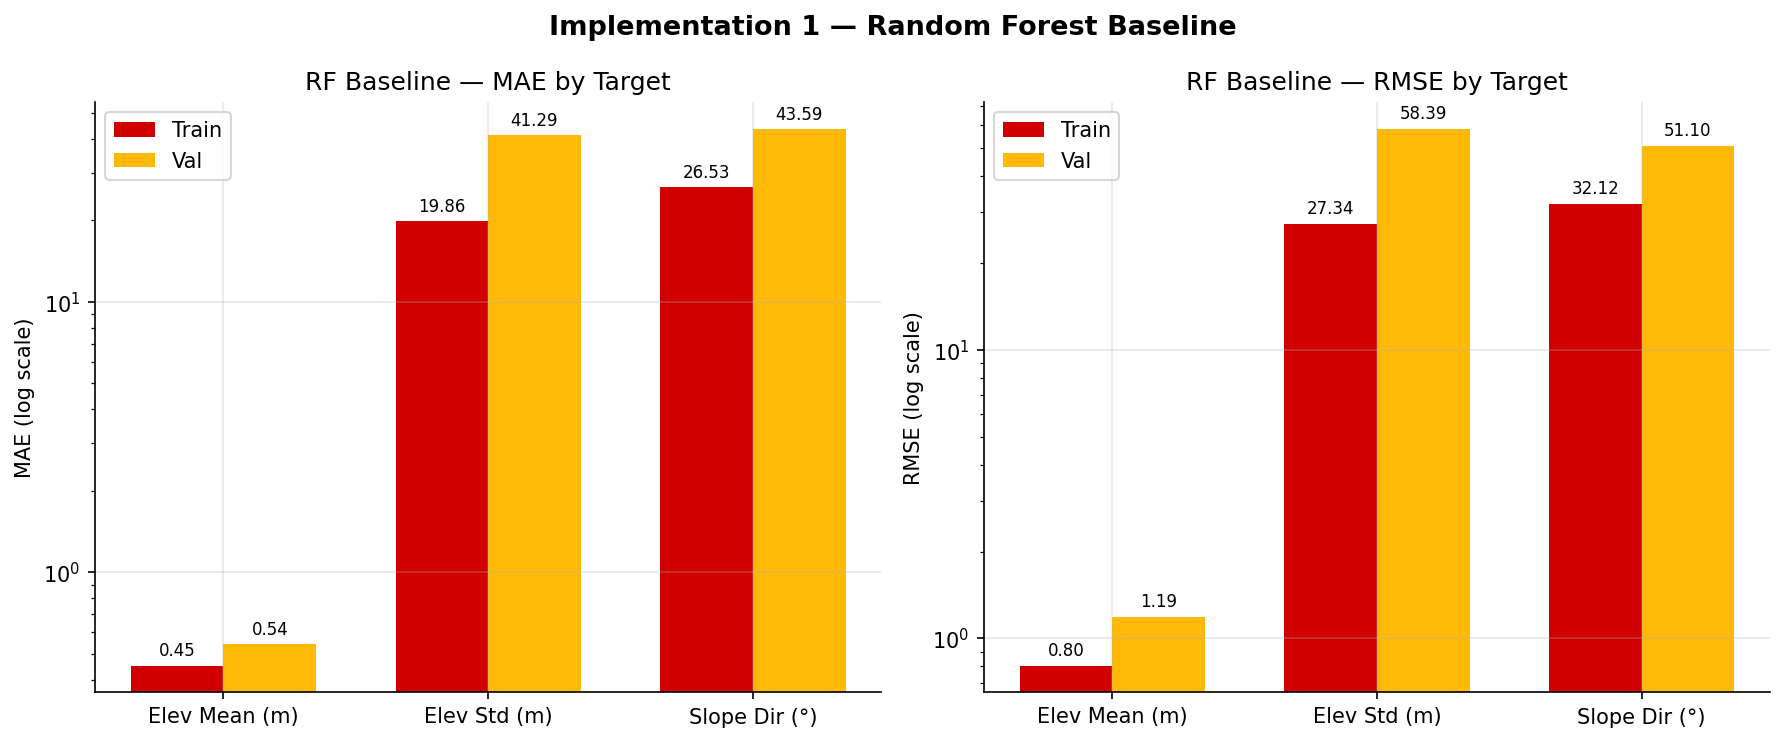

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

targets = ['elev_mean', 'elev_std', 'slope_dir']
labels  = ['Elev Mean (m)', 'Elev Std (m)', 'Slope Dir (°)']
x = np.arange(len(targets))
w = 0.35

for ax, metric in zip(axes, ['mae', 'rmse']):
    train_vals = [rf[t][f'train_{metric}'] for t in targets]
    val_vals   = [rf[t][f'val_{metric}']   for t in targets]
    
    bars_train = ax.bar(x - w/2, train_vals, w, label='Train', color='#d00000')
    bars_val   = ax.bar(x + w/2, val_vals,   w, label='Val',   color='#ffba08')
    
    ax.set_yscale('log')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel(metric.upper() + ' (log scale)')
    ax.set_title(f'RF Baseline — {metric.upper()} by Target')
    ax.legend()
    
    for bar in bars_train:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.05,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
    for bar in bars_val:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.05,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('Implementation 1 — Random Forest Baseline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

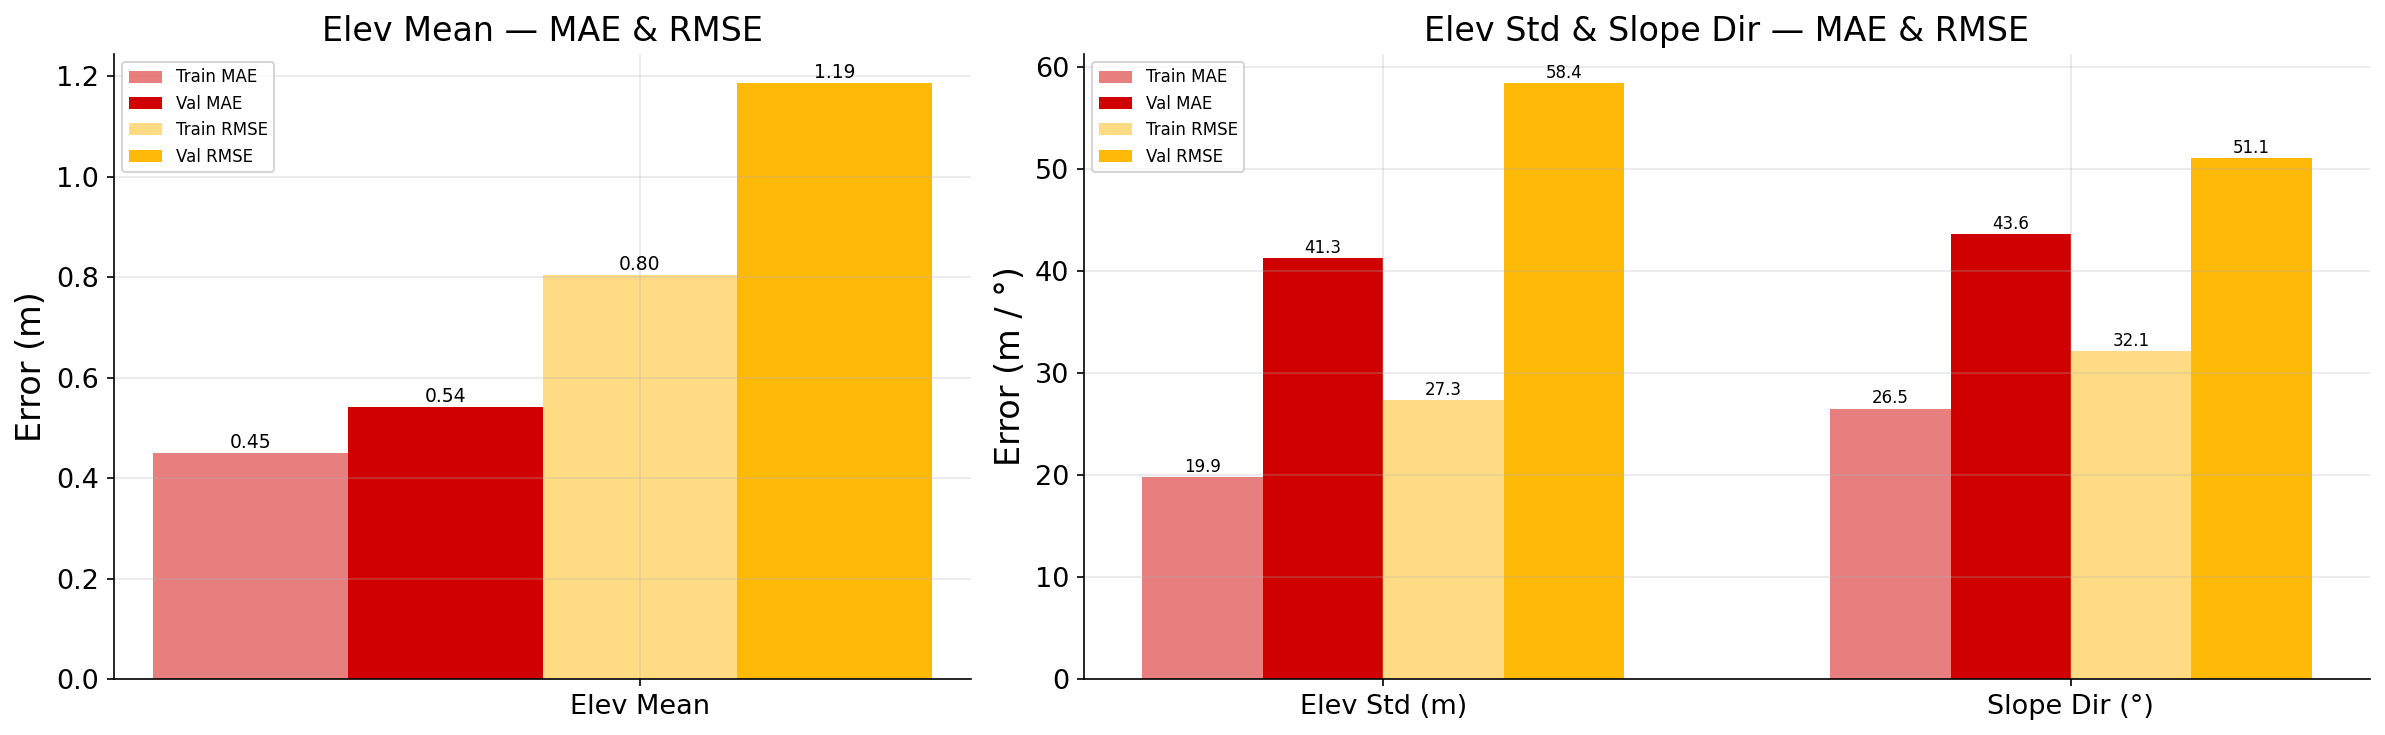

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [2, 3]})

# Left: elev_mean alone (sub-meter scale)
ax = axes[0]
targets_left = ['elev_mean']
labels_left  = ['Elev Mean']
x = np.arange(len(targets_left))
w = 0.35

for metric, color in zip(['mae', 'rmse'], ['#d00000', '#ffba08']):
    train_val = rf['elev_mean'][f'train_{metric}']
    val_val   = rf['elev_mean'][f'val_{metric}']
    offset = -w/2 if metric == 'mae' else w/2
    b1 = ax.bar(0 + offset - w/2, train_val, w/2, label=f'Train {metric.upper()}', color=color, alpha=0.5)
    b2 = ax.bar(0 + offset,       val_val,   w/2, label=f'Val {metric.upper()}',   color=color)
    ax.text(b1.patches[0].get_x() + b1.patches[0].get_width()/2, train_val + 0.01,
            f'{train_val:.2f}', ha='center', fontsize=9)
    ax.text(b2.patches[0].get_x() + b2.patches[0].get_width()/2, val_val + 0.01,
            f'{val_val:.2f}', ha='center', fontsize=9)

ax.set_xticks([0]); ax.set_xticklabels(['Elev Mean'])
ax.set_ylabel('Error (m)')
ax.set_title('Elev Mean — MAE & RMSE')
ax.legend(fontsize=8)

# Right: elev_std and slope_dir (tens of meters / degrees)
ax = axes[1]
targets_right = ['elev_std', 'slope_dir']
labels_right  = ['Elev Std (m)', 'Slope Dir (°)']
x = np.arange(len(targets_right))
w = 0.35

for metric, color in zip(['mae', 'rmse'], ['#d00000', '#ffba08']):
    train_vals = [rf[t][f'train_{metric}'] for t in targets_right]
    val_vals   = [rf[t][f'val_{metric}']   for t in targets_right]
    offset = -w/2 if metric == 'mae' else w/2
    bars_t = ax.bar(x + offset - w/4, train_vals, w/2, label=f'Train {metric.upper()}', color=color, alpha=0.5)
    bars_v = ax.bar(x + offset + w/4, val_vals,   w/2, label=f'Val {metric.upper()}',   color=color)
    for b, v in zip(bars_t, train_vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.1f}', ha='center', fontsize=8)
    for b, v in zip(bars_v, val_vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.1f}', ha='center', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(labels_right)
ax.set_ylabel('Error (m / °)')
ax.set_title('Elev Std & Slope Dir — MAE & RMSE')
ax.legend(fontsize=8)

for ax in axes:
    ax.title.set_fontsize(16)
    ax.xaxis.label.set_fontsize(16)
    ax.yaxis.label.set_fontsize(16)
    ax.tick_params(axis='both', labelsize=13)

plt.tight_layout()
plt.show()

In [5]:
with open('../outputs/deeplearning/impl2/results.json') as f:
    impl2 = json.load(f)

print(f"Impl2 best val RMSE: {impl2['best_val_rmse']:.2f}m")

Impl2 best val RMSE: 74.38m


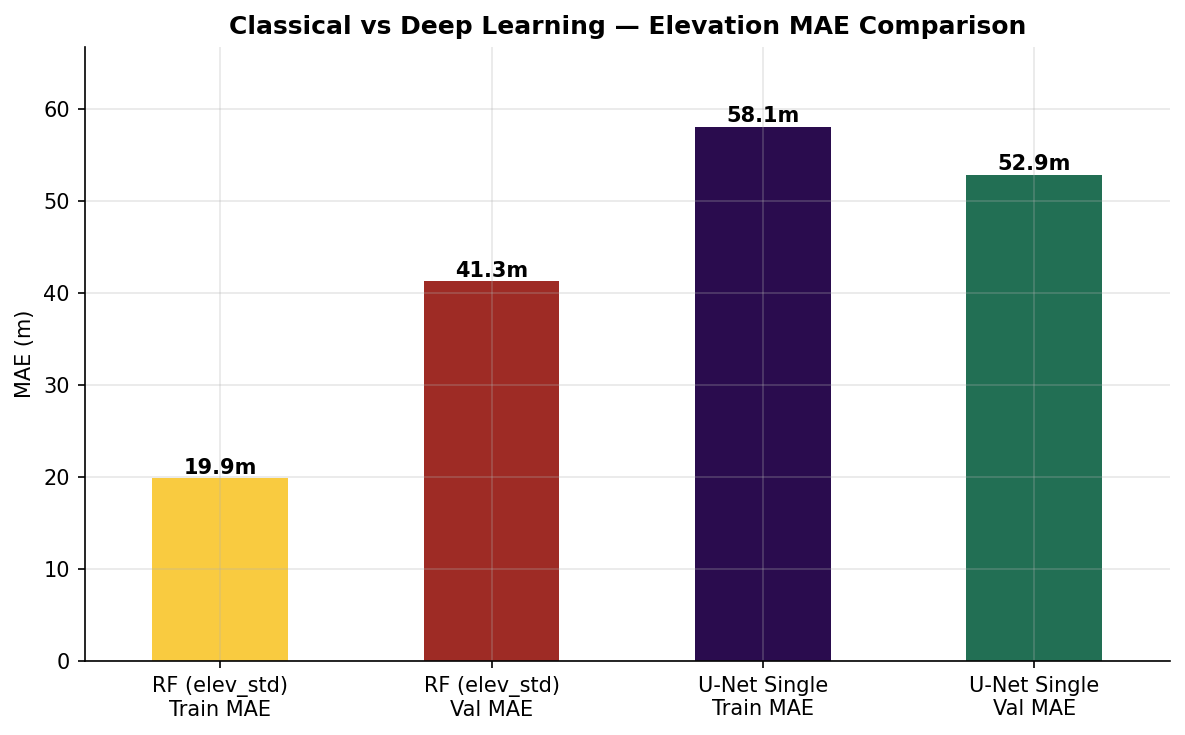

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

methods = ['RF (elev_std)\nTrain MAE', 'RF (elev_std)\nVal MAE', 'U-Net Single\nTrain MAE', 'U-Net Single\nVal MAE']
values  = [rf['elev_std']['train_mae'], rf['elev_std']['val_mae'],
           impl2['history']['train_loss'][-1], min(impl2['history']['val_mae'])]
colors  = ['#f9cb40', '#9e2b25', '#2a0c4e', '#226f54']
alphas  = [0.6, 1.0, 0.6, 1.0]

bars = ax.bar(methods, values, color=colors, width=0.5)
ax.set_xlim(-0.5, 3.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}m', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('MAE (m)')
ax.set_title('Classical vs Deep Learning — Elevation MAE Comparison', fontweight='bold')
ax.set_ylim(0, max(values) * 1.15)

plt.tight_layout()
plt.show()

In [8]:
with open('../outputs/deeplearning/impl3/results.json') as f:
    impl3 = json.load(f)

with open('../outputs/deeplearning/impl4/results.json') as f:
    impl4 = json.load(f)

print("Loaded impl3 and impl4")

Loaded impl3 and impl4


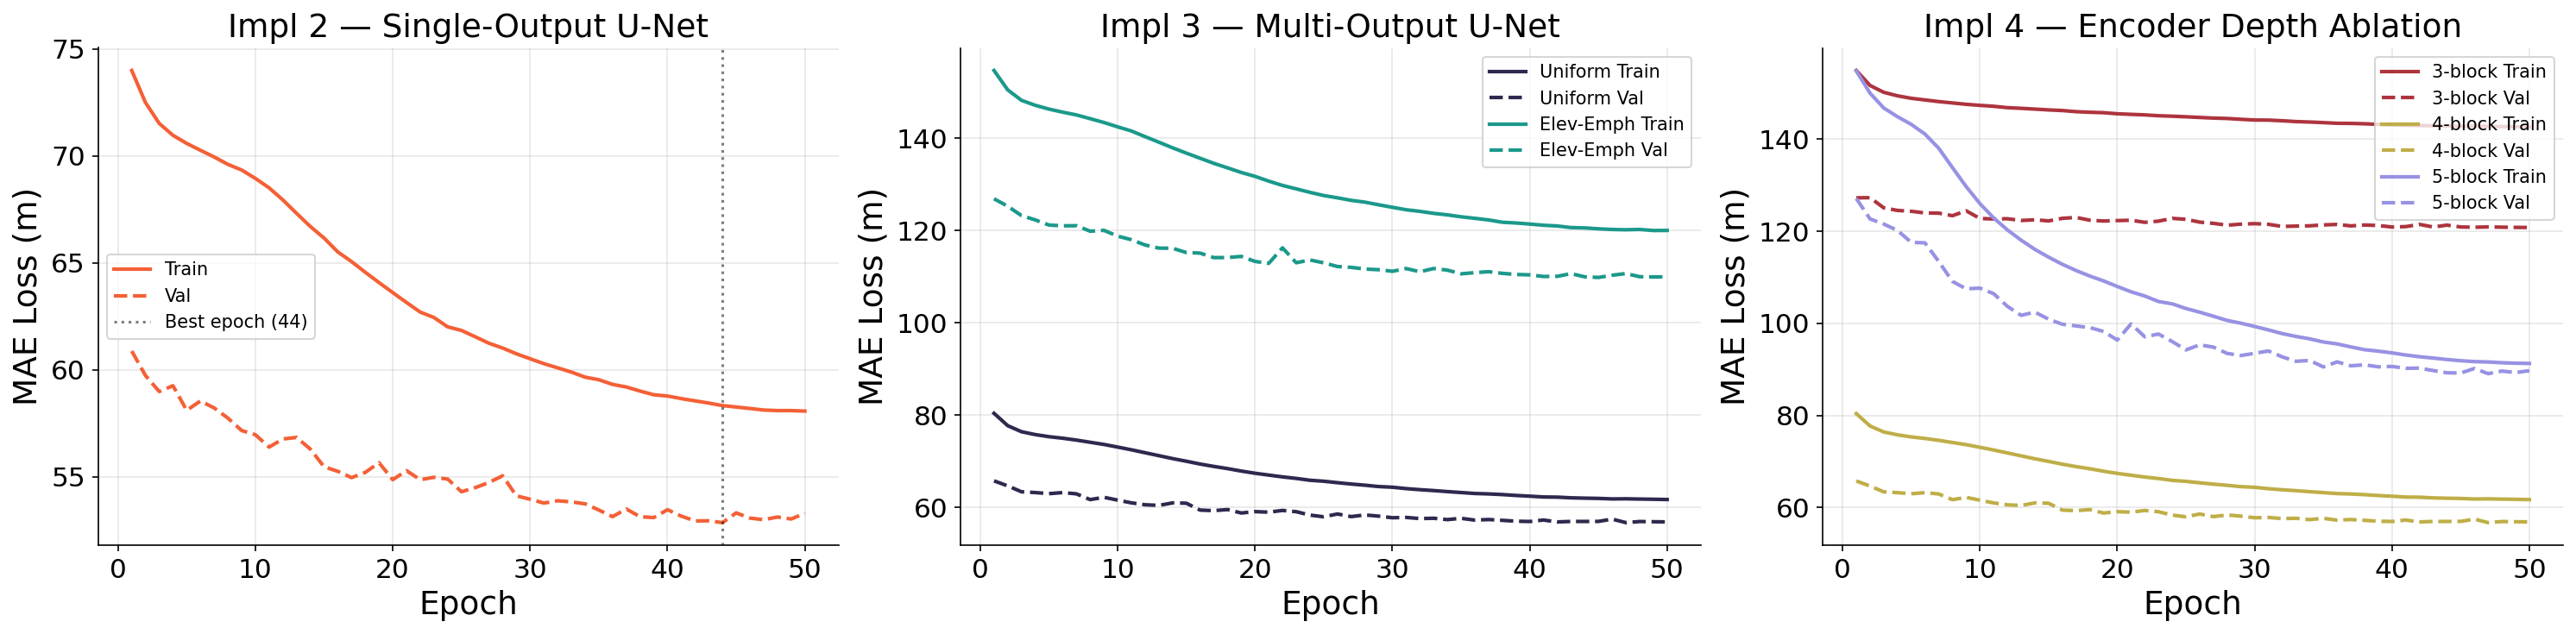

In [29]:
epochs = range(1, 51)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

plt.rcParams.update({
    'axes.labelsize': 18,
    'axes.titlesize': 18,
    'legend.fontsize': 10,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
})

# --- Left: Impl2 ---
ax = axes[0]
ax.plot(epochs, impl2['history']['train_loss'], color='#f46036', linewidth=2, label='Train')
ax.plot(epochs, impl2['history']['val_loss'],   color='#f46036', linewidth=2, linestyle='--', label='Val')
ax.axvline(impl2['best_epoch'], color='black', linestyle=':', alpha=0.5, label=f"Best epoch ({impl2['best_epoch']})")
ax.set_title('Impl 2 — Single-Output U-Net')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE Loss (m)')
ax.legend()

# --- Middle: Impl3 ---
ax = axes[1]
ax.plot(epochs, impl3['histories']['uniform']['train_loss'],   color='#2E294E', linewidth=2, label='Uniform Train')
ax.plot(epochs, impl3['histories']['uniform']['val_loss'],     color='#2E294E', linewidth=2, linestyle='--', label='Uniform Val')
ax.plot(epochs, impl3['histories']['elev_emph']['train_loss'], color='#1B998B', linewidth=2, label='Elev-Emph Train')
ax.plot(epochs, impl3['histories']['elev_emph']['val_loss'],   color='#1B998B', linewidth=2, linestyle='--', label='Elev-Emph Val')
ax.set_title('Impl 3 — Multi-Output U-Net')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE Loss (m)')
ax.legend()

# --- Right: Impl4 ---
ax = axes[2]
ax.plot(epochs, impl4['histories']['3block']['train_loss'], color='#ad343e', linewidth=2, label='3-block Train')
ax.plot(epochs, impl4['histories']['3block']['val_loss'],   color='#ad343e', linewidth=2, linestyle='--', label='3-block Val')
ax.plot(epochs, impl4['histories']['4block']['train_loss'], color='#bfae48', linewidth=2, label='4-block Train')
ax.plot(epochs, impl4['histories']['4block']['val_loss'],   color='#bfae48', linewidth=2, linestyle='--', label='4-block Val')
ax.plot(epochs, impl4['histories']['5block']['train_loss'], color='#9792e3', linewidth=2, label='5-block Train')
ax.plot(epochs, impl4['histories']['5block']['val_loss'],   color='#9792e3', linewidth=2, linestyle='--', label='5-block Val')
ax.set_title('Impl 4 — Encoder Depth Ablation')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE Loss (m)')
ax.legend()

plt.tight_layout()
plt.show()

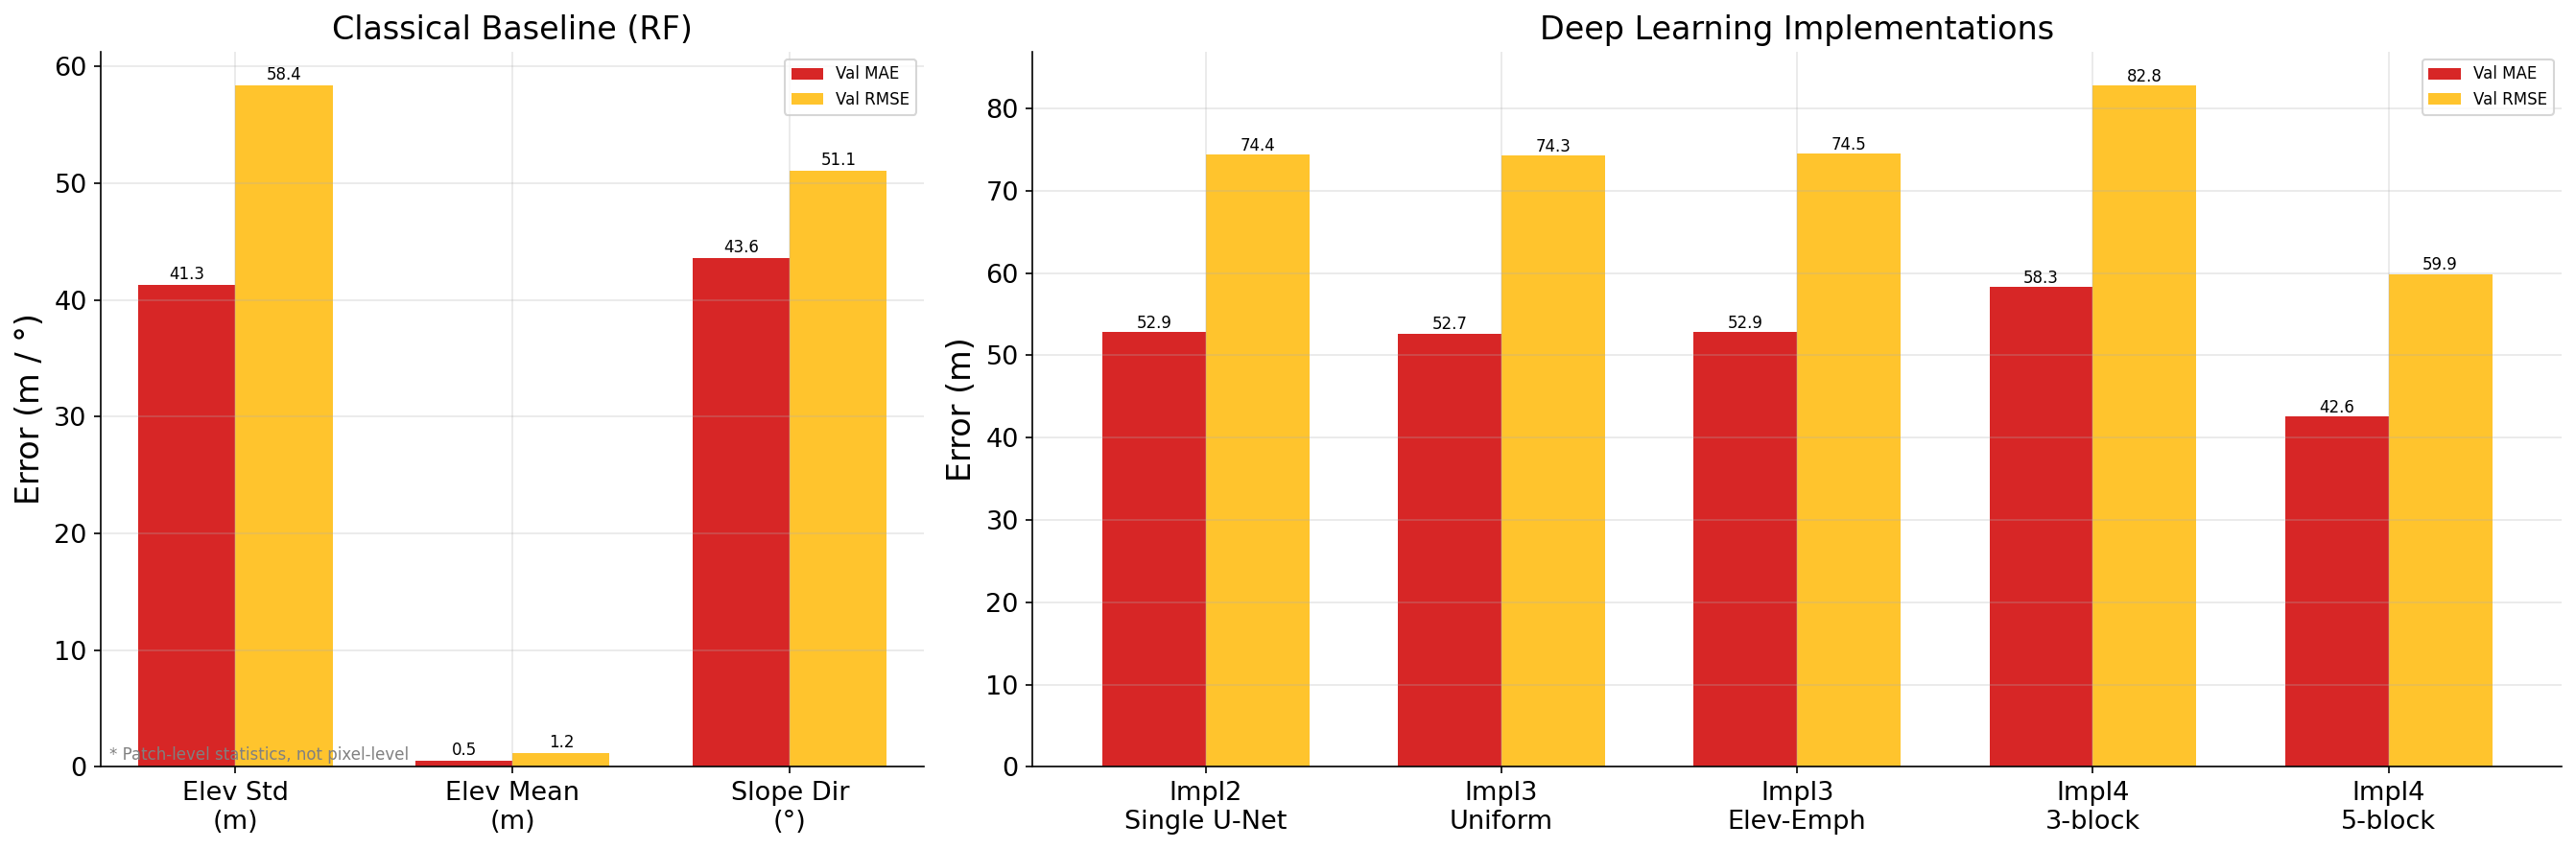

In [37]:
# ── Font control ──────────────────────────────────────────
FONT = {
    'title':      16,
    'axis_label': 16,
    'tick':       13,
    'bar_label':  8,
    'legend':     8,
}

# ── Data ──────────────────────────────────────────────────
rf_labels  = ['Elev Std\n(m)', 'Elev Mean\n(m)', 'Slope Dir\n(°)']
rf_keys    = ['elev_std', 'elev_mean', 'slope_dir']
rf_mae     = [rf[k]['val_mae']  for k in rf_keys]
rf_rmse    = [rf[k]['val_rmse'] for k in rf_keys]

dl_labels  = ['Impl2\nSingle U-Net', 'Impl3\nUniform', 'Impl3\nElev-Emph',
              'Impl4\n3-block', 'Impl4\n5-block']
dl_mae     = [min(impl2['history']['val_mae']),
              min(impl3['histories']['uniform']['val_elev_mae']),
              min(impl3['histories']['elev_emph']['val_elev_mae']),
              min(impl4['histories']['3block']['val_elev_mae']),
              min(impl4['histories']['5block']['val_elev_mae'])]
dl_rmse    = [impl2['best_val_rmse'],
              impl3['best_elev_rmse'],
              min(impl3['histories']['elev_emph']['val_elev_rmse']),
              impl4['variants']['3block']['best_elev_rmse'],
              impl4['variants']['5block']['best_elev_rmse']]

# ── Figure ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6),
                         gridspec_kw={'width_ratios': [35, 65]})

x_rf = np.arange(len(rf_labels))
x_dl = np.arange(len(dl_labels))
w = 0.35

# --- Left: RF ---
ax = axes[0]
b1 = ax.bar(x_rf - w/2, rf_mae,  w, label='Val MAE',  color='#d00000', alpha=0.85)
b2 = ax.bar(x_rf + w/2, rf_rmse, w, label='Val RMSE', color='#ffba08', alpha=0.85)
for bar, v in zip(b1, rf_mae):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
            f'{v:.1f}', ha='center', fontsize=FONT['bar_label'])
for bar, v in zip(b2, rf_rmse):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
            f'{v:.1f}', ha='center', fontsize=FONT['bar_label'])
ax.set_xticks(x_rf)
ax.set_xticklabels(rf_labels, fontsize=FONT['tick'])
ax.set_ylabel('Error (m / °)', fontsize=FONT['axis_label'])
ax.set_title('Classical Baseline (RF)', fontsize=FONT['title'])
ax.tick_params(axis='y', labelsize=FONT['tick'])
ax.legend(fontsize=FONT['legend'])
ax.annotate('* Patch-level statistics, not pixel-level',
            xy=(0.01, 0.01), xycoords='axes fraction',
            fontsize=8, color='gray')

# --- Right: DL ---
ax = axes[1]
b3 = ax.bar(x_dl - w/2, dl_mae,  w, label='Val MAE',  color='#d00000', alpha=0.85)
b4 = ax.bar(x_dl + w/2, dl_rmse, w, label='Val RMSE', color='#ffba08', alpha=0.85)
for bar, v in zip(b3, dl_mae):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
            f'{v:.1f}', ha='center', fontsize=FONT['bar_label'])
for bar, v in zip(b4, dl_rmse):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
            f'{v:.1f}', ha='center', fontsize=FONT['bar_label'])
ax.set_xticks(x_dl)
ax.set_xticklabels(dl_labels, fontsize=FONT['tick'])
ax.set_ylabel('Error (m)', fontsize=FONT['axis_label'])
ax.set_title('Deep Learning Implementations', fontsize=FONT['title'])
ax.tick_params(axis='y', labelsize=FONT['tick'])
ax.legend(fontsize=FONT['legend'])

plt.tight_layout()
plt.show()

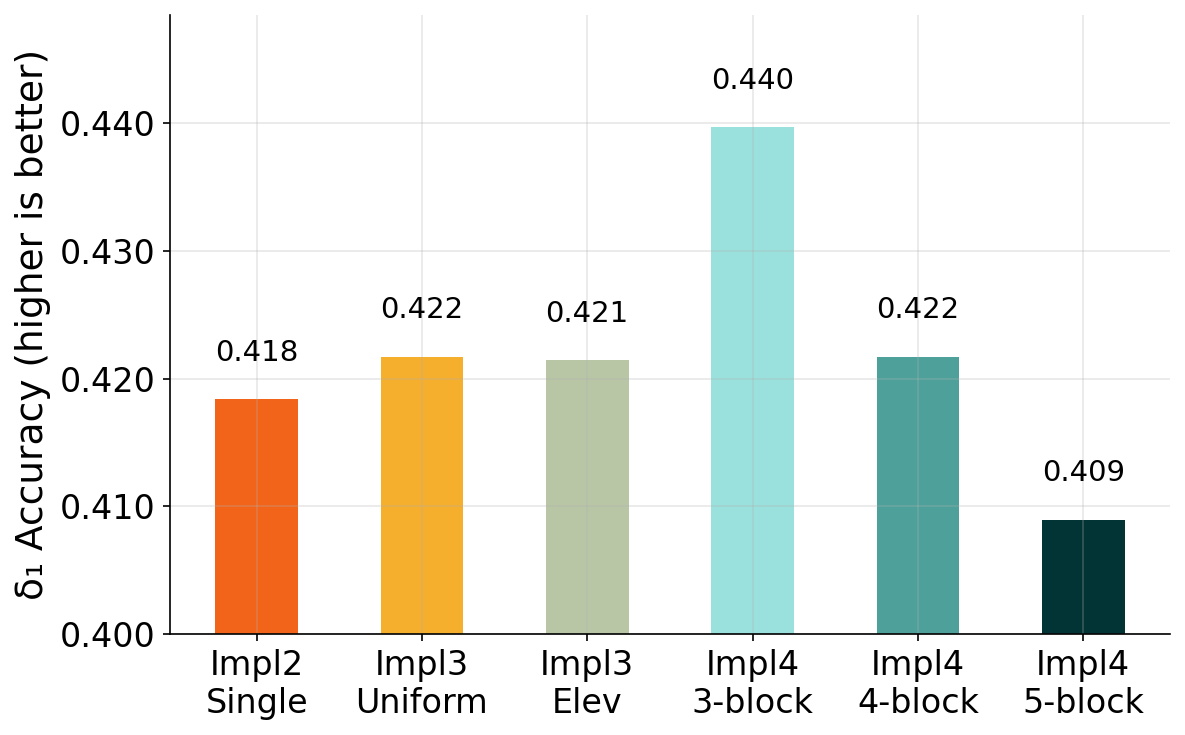

In [60]:
# ── δ₁ at best RMSE epoch ─────────────────────────────────
def best_delta1(rmse_list, delta1_list):
    best_idx = int(np.argmin(rmse_list))
    return delta1_list[best_idx]

dl_labels = ['Impl2\nSingle', 'Impl3\nUniform', 'Impl3\nElev',
             'Impl4\n3-block', 'Impl4\n4-block', 'Impl4\n5-block']

dl_delta1 = [
    impl2['history']['val_delta1'][impl2['best_epoch'] - 1],
    best_delta1(impl3['histories']['uniform']['val_elev_rmse'],
                impl3['histories']['uniform']['val_elev_delta1']),
    best_delta1(impl3['histories']['elev_emph']['val_elev_rmse'],
                impl3['histories']['elev_emph']['val_elev_delta1']),
    best_delta1(impl4['histories']['3block']['val_elev_rmse'],
                impl4['histories']['3block']['val_elev_delta1']),
    best_delta1(impl4['histories']['4block']['val_elev_rmse'],
                impl4['histories']['4block']['val_elev_delta1']),
    best_delta1(impl4['histories']['5block']['val_elev_rmse'],
                impl4['histories']['5block']['val_elev_delta1']),
]

# ── Plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(dl_labels))
w = 0.5
colors = ['#f26419', '#f6ae2d', '#758e4f', '#03b5aa', '#037971', '#023436']
alphas = [1.0, 1.0, 0.5, 0.4, 0.7, 1.0]

bars = ax.bar(x, dl_delta1, w, color=colors)
for bar, val, alpha in zip(bars, dl_delta1, alphas):
    bar.set_alpha(alpha)
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
            f'{val:.3f}', ha='center', fontsize=14)

ax.set_xticks(x)
ax.set_xticklabels(dl_labels, fontsize=16)
ax.set_ylabel('δ₁ Accuracy (higher is better)', fontsize=18)
ax.tick_params(axis='y', labelsize=16)
ax.set_ylim(0.4, max(dl_delta1) * 1.02)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3f}'))

plt.tight_layout()
plt.show()

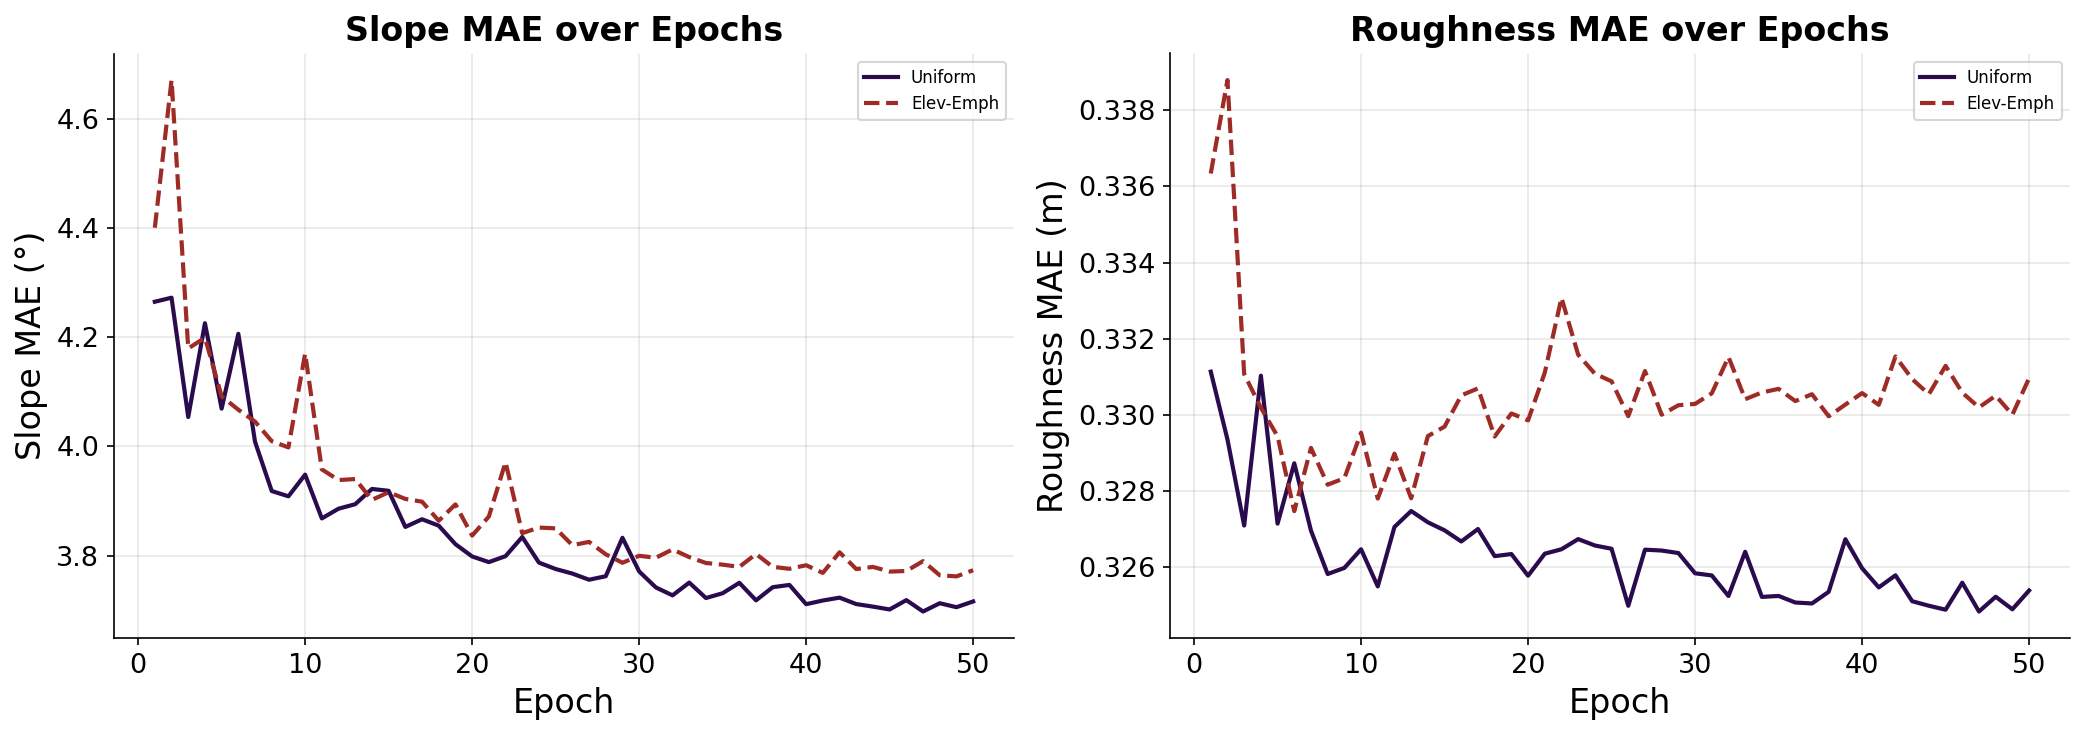

In [62]:
epochs = range(1, 51)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Slope MAE ---
ax = axes[0]
ax.plot(epochs, impl3['histories']['uniform']['val_slope_mae'],
        color='#2a0c4e', linewidth=2, label='Uniform')
ax.plot(epochs, impl3['histories']['elev_emph']['val_slope_mae'],
        color='#9e2b25', linewidth=2, linestyle='--', label='Elev-Emph')
ax.set_xlabel('Epoch', fontsize=FONT['axis_label'])
ax.set_ylabel('Slope MAE (°)', fontsize=FONT['axis_label'])
ax.set_title('Slope MAE over Epochs', fontsize=FONT['title'], fontweight='bold')
ax.tick_params(axis='both', labelsize=FONT['tick'])
ax.legend(fontsize=FONT['legend'])

# --- Right: Roughness MAE ---
ax = axes[1]
ax.plot(epochs, impl3['histories']['uniform']['val_rough_mae'],
        color='#2a0c4e', linewidth=2, label='Uniform')
ax.plot(epochs, impl3['histories']['elev_emph']['val_rough_mae'],
        color='#9e2b25', linewidth=2, linestyle='--', label='Elev-Emph')
ax.set_xlabel('Epoch', fontsize=FONT['axis_label'])
ax.set_ylabel('Roughness MAE (m)', fontsize=FONT['axis_label'])
ax.set_title('Roughness MAE over Epochs', fontsize=FONT['title'], fontweight='bold')
ax.tick_params(axis='both', labelsize=FONT['tick'])
ax.legend(fontsize=FONT['legend'])

plt.tight_layout()
plt.show()